# A posterior over the 3D subsurface: multiphysics joint inversion

This is the inverse problem at the heart of exploration: given everything we can measure about a patch of
earth -- wells, seismic, gravity, and the estimates other inversions hand us -- produce a *posterior over
the complete three-dimensional subsurface*, and then decide where to drill. No one modality sees the rock;
each sees one shadow of it through one piece of physics. The job is to fuse them, and to report not a
single model but the **distribution of earths consistent with the data** -- many plausible 3-D
reconstructions, each with its probability.

A single latent **porosity field** lives on a 3-D grid; rock physics turns it into the **velocity** the
seismic wave equation responds to and the **density** the gravity field responds to -- one geology, three
coupled fields (the *multiphysics*). Each measurement is a forward operator on that shared field: a
**Helmholtz wave-equation PDE** for seismic, a **Newtonian potential** for gravity, point sampling for
wells, a smoothing operator for a tomography estimate. Stacking their likelihoods with a spatial prior
gives a **joint Gaussian posterior** over the whole field. We then **draw an ensemble** of 3-D earths from
it, turn it into a probabilistic image of the reservoir and a set of geological scenarios with
probabilities, and let **Bayesian optimization** propose the next well against the ensemble.

The rock physics is **real** -- porosity and facies of the Hugoton-Panoma gas field (SEG-2016 / Dubois
2007 well logs). The geophysical surveys are simulated forward from that real-property earth (the honest
way to run a controlled joint inversion without proprietary co-located surveys) and then recovered. Where
field geometry is not public we use an approximate layout and say so; the physics never leans on it.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import time
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D            # noqa: enables 3-D subsurface rendering
from mixle_pde.pde_solve import laplacian          # PDE machinery: differentiable sparse operators
from mixle_pde.ops import make_ops
from mixle.doe import minimize                       # Bayesian optimization for the drilling decision

torch.set_default_dtype(torch.float64); ops = make_ops(); rng = np.random.RandomState(1)
def panel(ncol=1, w=5.0, h=3.2):
    fig, ax = plt.subplots(1, ncol, figsize=(w * ncol, h)); return fig, (ax if ncol > 1 else [ax])
print('multiphysics joint inversion: seismic (Helmholtz PDE) + gravity (potential) + wells + tomography')

multiphysics joint inversion: seismic (Helmholtz PDE) + gravity (potential) + wells + tomography


## 1. The real rock: porosity from the Hugoton-Panoma logs

The one thing we treat as ground truth is the rock physics, and it comes from real wells. The SEG-2016
release gives porosity (`PHIND`) and a core facies on every half-foot of ten wells. Because neutron
porosity is inflated by clay in the shaly background, we characterise the target by its *developed*
(high-porosity) reservoir zones versus the tight matrix, read off the real porosity distribution. That
positive contrast is what the geophysics must detect.

tight matrix porosity 0.061  vs developed reservoir 0.162  ->  contrast +0.101


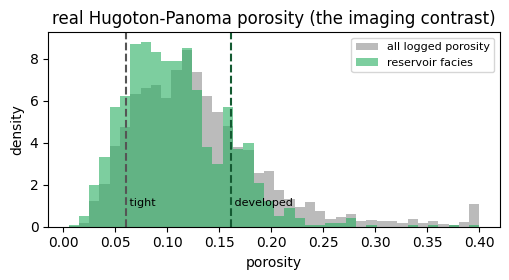

In [2]:
logs = pd.read_csv('../../data/hugoton_panoma/training_wells.csv')
logs['phi'] = np.clip(logs['PHIND'], 0, 40) / 100.0
phi_res = logs[logs['Facies'].isin([7, 8, 9])]['phi']          # dolomite + packstone/grainstone + bafflestone
PHI_TIGHT, PHI_PAY = float(logs['phi'].quantile(0.10)), float(phi_res.quantile(0.85))
DPHI = PHI_PAY - PHI_TIGHT
print(f'tight matrix porosity {PHI_TIGHT:.3f}  vs developed reservoir {PHI_PAY:.3f}  ->  contrast {DPHI:+.3f}')

fig, ax = panel(1, w=5.2, h=2.9)
ax[0].hist(logs['phi'], bins=40, color='#bbb', density=True, label='all logged porosity')
ax[0].hist(phi_res, bins=40, color='#27AE60', alpha=0.6, density=True, label='reservoir facies')
ax[0].axvline(PHI_TIGHT, c='#555', ls='--'); ax[0].axvline(PHI_PAY, c='#145A32', ls='--')
ax[0].text(PHI_TIGHT, 1, ' tight', fontsize=8); ax[0].text(PHI_PAY, 1, ' developed', fontsize=8)
ax[0].set(xlabel='porosity', ylabel='density', title='real Hugoton-Panoma porosity (the imaging contrast)')
ax[0].legend(fontsize=8); plt.tight_layout(); plt.show()

## 2. The 3-D earth model

We work on a real three-dimensional grid (28 x 28 x 20 voxels, ~210 m cells over a 6 x 6 x 2.4 km block).
This is an *exploration-stage* problem: only six appraisal wells, placed off the structural crest, so the
reservoir between them is genuinely uncertain -- which is exactly when an ensemble of possible earths
earns its keep. The true earth is a tight background with a porous reservoir body draped over a gentle
anticline; its porosity contrast is the real number above. We render it as a 3-D volume, not a stack of
slices.

grid 28x28x20 = 15680 voxels, 222 m cells; reservoir region = 2736 voxels; 6 wells


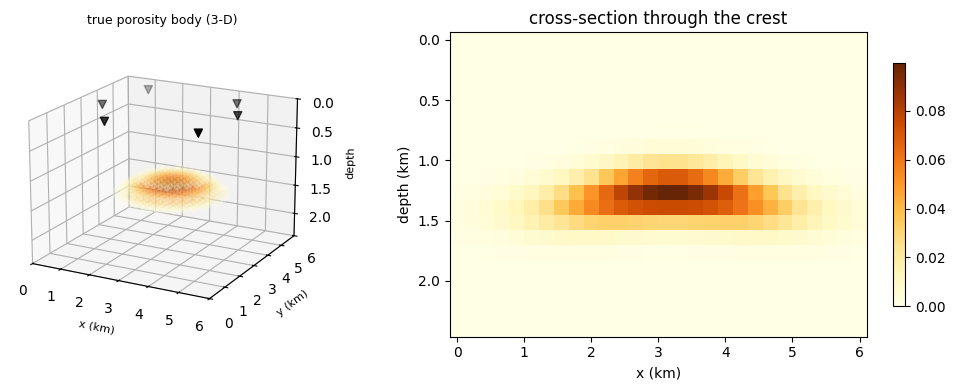

In [3]:
nx, ny, nz = 28, 28, 20; N = nx * ny * nz
Lx = Ly = 6.0; Lz = 2.4; h = Lx / (nx - 1)
gx, gy, gz = np.linspace(0, Lx, nx), np.linspace(0, Ly, ny), np.linspace(0, Lz, nz)
GX, GY, GZ = np.meshgrid(gx, gy, gz, indexing='ij'); vox = np.stack([GX.ravel(), GY.ravel(), GZ.ravel()], 1)
node = lambda ix, iy, iz: ix * ny * nz + iy * nz + iz
WELLXY = np.array([[1.4, 4.8], [4.6, 4.6], [1.0, 2.6], [5.2, 3.4], [2.0, 1.0], [5.0, 1.2]])   # 6 appraisal wells, off-crest

crest = 1.45 - 0.18 * np.exp(-((GX - 3.2) ** 2 + (GY - 3.0) ** 2) / 3.0)        # gentle structural high
body = np.exp(-((GX - 3.2) ** 2 + (GY - 3.0) ** 2) / 2.6) * np.exp(-((GZ - crest) ** 2) / 0.05)
dphi_true = (DPHI * body).ravel()
roi = (np.abs(GX.ravel() - 3.1) < 2.1) & (np.abs(GY.ravel() - 3.0) < 2.1) & (GZ.ravel() > 0.9) & (GZ.ravel() < 2.0)
ridx = np.where(roi)[0]; Nr = len(ridx); vx = vox[ridx]; dV = h ** 3
print(f'grid {nx}x{ny}x{nz} = {N} voxels, {h*1000:.0f} m cells; reservoir region = {Nr} voxels; {len(WELLXY)} wells')

def render3d(ax, field, title, cmap='YlOrBr', cut=None, vmax=None, cbar=False):
    F = np.asarray(field).reshape(nx, ny, nz); cut = 0.30 * DPHI if cut is None else cut
    m = F > cut
    p = ax.scatter(GX[m], GY[m], GZ[m], c=F[m], cmap=cmap, s=18, alpha=0.30, vmin=cut,
                   vmax=(DPHI if vmax is None else vmax), edgecolor='none')
    ax.set_xlabel('x (km)', fontsize=8); ax.set_ylabel('y (km)', fontsize=8); ax.set_zlabel('depth', fontsize=8)
    ax.set_xlim(0, Lx); ax.set_ylim(0, Ly); ax.set_zlim(Lz, 0); ax.view_init(elev=18, azim=-62); ax.set_title(title, fontsize=9)
    return p

fig = plt.figure(figsize=(11, 4))
axA = fig.add_subplot(121, projection='3d'); render3d(axA, dphi_true, 'true porosity body (3-D)')
axA.scatter(WELLXY[:, 0], WELLXY[:, 1], np.zeros(len(WELLXY)), c='k', marker='v', s=34)
axB = fig.add_subplot(122)
im = axB.pcolormesh(gx, gz, dphi_true.reshape(nx, ny, nz)[:, ny // 2, :].T, cmap='YlOrBr', shading='auto')
axB.invert_yaxis(); axB.set(xlabel='x (km)', ylabel='depth (km)', title='cross-section through the crest')
plt.colorbar(im, ax=axB, shrink=0.8); plt.tight_layout(); plt.show()

## 3. The multiphysics coupling: one geology, three fields

Porosity is the latent we infer, but no instrument measures it directly at depth. Rock physics couples it
to the fields the instruments respond to: porous rock is **slower** (velocity drops) and **lighter**
(density drops). We linearise these about the background so one porosity anomaly drives a velocity anomaly
the wave equation sees and a density anomaly the gravity field sees -- the shared latent that makes seismic
and gravity talk to each other.

In [4]:
Vp0 = 4.0; dVp_dphi = -6.0
dm_dphi = -2 * dVp_dphi / Vp0 ** 3                # d(1/Vp^2)/d(phi)
drho_dphi = -(2.65 - 1.0)                         # density drop per unit porosity
m_bg = (1.0 / Vp0 ** 2) * np.ones(N)
print(f'porosity -> slowness^2 sensitivity {dm_dphi:+.4f} (seismic);  '
      f'porosity -> density sensitivity {drho_dphi:+.2f} g/cc (gravity)')

porosity -> slowness^2 sensitivity +0.1875 (seismic);  porosity -> density sensitivity -1.65 g/cc (gravity)


## 4. Forward model I -- seismic, a wave-equation PDE

The seismic datum solves a partial differential equation. In the frequency domain the wavefield `u` obeys
the **Helmholtz equation** `-(lap + omega^2 / Vp(x)^2) u = source`, with an absorbing layer at the edges.
We assemble that operator on the grid and solve it with `mixle`'s differentiable sparse solver -- a
genuine PDE solve per source per frequency -- and from the background wavefields build the **Born
operator** `A_seis`, the linear map from a porosity anomaly to the scattered field at the receivers. The
survey is sparse (an exploration 2-D-style spread), so the seismic constrains structure without pinning
every voxel.

6 sources x 9 receivers x 2 freqs = 108 seismic data; 30 Helmholtz PDE solves in 18s


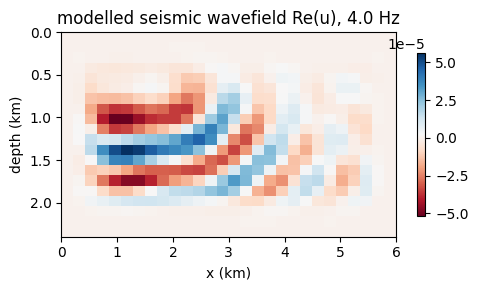

In [5]:
d2e = np.minimum.reduce([GX, Lx - GX, GY, Ly - GY, GZ, Lz - GZ]).ravel()
sig = np.where(d2e < 0.6, (1 - d2e / 0.6) ** 2, 0.0) * 16.0
Lr, Lc, Lv, _ = laplacian((nx, ny, nz), spacing=h)
bm = np.ones((nx, ny, nz)); bm[0] = bm[-1] = bm[:, 0] = bm[:, -1] = bm[:, :, 0] = bm[:, :, -1] = 0
interior = torch.as_tensor(np.where(bm.ravel() > 0)[0]); sig_t = torch.as_tensor(sig[bm.ravel() > 0])
freqs = [4.0, 6.0]; mt = torch.as_tensor(m_bg)
def helm(w):
    diag = ((w ** 2) * mt[interior] - 1j * w * sig_t).to(torch.complex128)
    return torch.cat([Lr, interior]), torch.cat([Lc, interior]), torch.cat([Lv.to(torch.complex128), -diag]), N
src = [node(ix, iy, 1) for ix in (6, 21) for iy in (6, 14, 21)]                          # 6 sources
rec = np.array([node(ix, iy, 1) for ix in range(4, nx - 3, 7) for iy in range(4, ny - 3, 7)])  # ~9 receivers
def wf(s, w):
    r, c, vv, n = helm(w); b = torch.zeros(N, dtype=torch.complex128); b[s] = 1.0 / h ** 2
    return ops.sparse_solve(r, c, vv, n, b).detach().numpy()

t0 = time.time(); Arows = []
for f in freqs:
    w = 2 * np.pi * f
    fields = {p: wf(p, w)[ridx] for p in set(src) | set(rec.tolist())}      # each point source solved once
    for s in src:
        for rr in rec: Arows.append((h ** 2) * (w ** 2) * fields[s] * fields[rr])
A_seis = np.array(Arows) * dm_dphi
print(f'{len(src)} sources x {len(rec)} receivers x {len(freqs)} freqs = {A_seis.shape[0]} seismic data; '
      f'{2 * len(set(src) | set(rec.tolist()))} Helmholtz PDE solves in {time.time() - t0:.0f}s')

U = wf(src[2], 2 * np.pi * freqs[0]).reshape(nx, ny, nz)
fig, ax = panel(1, w=5.0, h=3.0)
im = ax[0].imshow(U[:, ny // 2, :].real.T, origin='upper', extent=[0, Lx, Lz, 0], cmap='RdBu', aspect='auto')
ax[0].set(xlabel='x (km)', ylabel='depth (km)', title=f'modelled seismic wavefield Re(u), {freqs[0]} Hz')
plt.colorbar(im, ax=ax[0], shrink=0.8); plt.tight_layout(); plt.show()

## 5. Forward model II -- gravity, a potential field

Gravity responds to the *same* geology through different physics: the density anomaly perturbs the
gravitational potential (`lap(phi_g) = 4 pi G rho`), so the vertical gravity at a surface station is the
Newtonian integral of the density anomaly over the volume. That integral is linear in density, hence in
porosity -- a second forward operator `A_grav`, a smooth low-resolution view that constrains the bulk mass
the sparse seismic cannot.

81 gravity stations; anomaly amplitude 0.001 (schematic mGal)


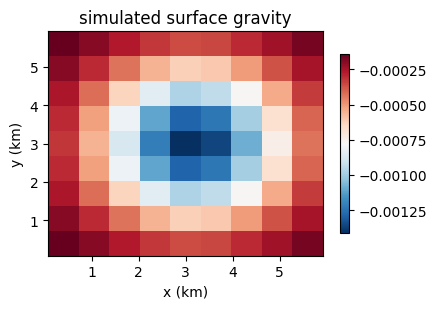

In [6]:
stations = np.array([[x, y, 0.0] for x in np.linspace(0.4, Lx - 0.4, 9) for y in np.linspace(0.4, Ly - 0.4, 9)])
dx = vx[None, :, 0] - stations[:, None, 0]; dy = vx[None, :, 1] - stations[:, None, 1]; dz = vx[None, :, 2] - stations[:, None, 2]
A_grav = 6.674e-3 * dz / ((dx * dx + dy * dy + dz * dz) ** 1.5 + 1e-6) * dV * drho_dphi
g_true = A_grav @ dphi_true[ridx]
print(f'{len(stations)} gravity stations; anomaly amplitude {np.abs(g_true).max():.3f} (schematic mGal)')

fig, ax = panel(1, w=4.4, h=3.2); ng = int(np.sqrt(len(stations)))
im = ax[0].pcolormesh(stations[:, 0].reshape(ng, ng), stations[:, 1].reshape(ng, ng), g_true.reshape(ng, ng),
                      cmap='RdBu_r', shading='auto')
ax[0].set(xlabel='x (km)', ylabel='y (km)', title='simulated surface gravity'); plt.colorbar(im, ax=ax[0], shrink=0.8)
plt.tight_layout(); plt.show()

## 6. The other modalities: wells and a tomography estimate

The **wells** measure porosity directly but only along their six tracks. And we fold in an **inverse
estimate from another method**: a traveltime-tomography velocity model, itself the output of a coarse
inversion, which behaves like a smoothed low-resolution sampling of the porosity. Reusing it as soft
pseudo-data is exactly how a real workflow recycles prior interpretations.

In [7]:
wsel = []
for wx, wy in WELLXY:
    wsel += list(np.where((np.abs(vx[:, 0] - wx) < h) & (np.abs(vx[:, 1] - wy) < h))[0])
wsel = np.unique(wsel); A_well = np.zeros((len(wsel), Nr)); A_well[np.arange(len(wsel)), wsel] = 1.0

tomo_pts = vx[::18]; ell_t = 0.5                  # coarse, smoothing tomography
Dt = ((tomo_pts[:, None, :] - vx[None, :, :]) ** 2).sum(-1)
W = np.exp(-Dt / (2 * ell_t ** 2)); A_tomo = W / W.sum(1, keepdims=True)
print(f'wells touch {len(wsel)} voxels; tomography = {A_tomo.shape[0]} smoothed samples (resolution {ell_t} km)')

wells touch 136 voxels; tomography = 152 smoothed samples (resolution 0.5 km)


## 7. The joint Bayesian inverse problem

Each modality `k` is a linear forward `d_k = A_k phi + noise` on the shared porosity field, Gaussian noise
`sigma_k`. With a Gaussian spatial prior (precision `Lambda`, an RBF correlation), the posterior is
Gaussian in closed form and information adds **in precision space**:

`P = Lambda + sum_k A_k^H A_k / sigma_k^2,    mean = P^{-1} sum_k A_k^H d_k / sigma_k^2,    cov = P^{-1}.`

That covariance is the whole point: its diagonal is the per-voxel uncertainty, and its Cholesky factor lets
us *draw whole 3-D earths* consistent with the data.

In [8]:
def noisy(A, x, rel, cpx=False):
    d = A @ x; nl = rel * np.abs(d).max()
    if cpx: return d + nl * (rng.randn(*d.shape) + 1j * rng.randn(*d.shape)) / np.sqrt(2), nl
    return d + nl * rng.randn(*d.shape), nl
d_s, ns = noisy(A_seis, dphi_true[ridx], 0.06, True)
d_g, ng = noisy(A_grav, dphi_true[ridx], 0.10)
d_w, nw = noisy(A_well, dphi_true[ridx], 0.02)
d_t, nt = noisy(A_tomo, dphi_true[ridx], 0.12)

D2 = ((vx[:, None, :] - vx[None, :, :]) ** 2).sum(-1)
Lam = np.linalg.inv((1.2 * DPHI) ** 2 * np.exp(-D2 / (2 * 0.6 ** 2)) + 1e-8 * np.eye(Nr))
TERMS = {'wells': (A_well, d_w, nw, False), 'gravity': (A_grav, d_g, ng, False),
         'tomography': (A_tomo, d_t, nt, False), 'seismic': (A_seis, d_s, ns, True)}

def posterior(keys):
    P = Lam.copy(); rhs = np.zeros(Nr)
    for k in keys:
        A, d, s, cpx = TERMS[k]
        if cpx: P += (A.conj().T @ A).real / s ** 2; rhs += (A.conj().T @ d).real / s ** 2
        else:   P += (A.T @ A) / s ** 2; rhs += (A.T @ d) / s ** 2
    Pinv = np.linalg.inv(P)
    return Pinv @ rhs, np.sqrt(np.clip(np.diag(Pinv), 0, None)), Pinv
print('joint posterior assembled on', Nr, 'voxels: prior precision +', len(TERMS), 'data precisions')

joint posterior assembled on 2736 voxels: prior precision + 4 data precisions


## 8. Multimodal fusion: information adds in precision

Add the modalities one at a time. With only six off-crest wells, no single modality recovers the reservoir
-- but each adds information, and the posterior uncertainty falls monotonically (the rigorous statement
that information adds in precision, `P = Lambda + sum_k A_k^H A_k/sigma_k^2`). Gravity supplies the bulk
mass, the tomography estimate fills the volume, and the sparse seismic sharpens the structure; together
they lift the reconstruction from a near-blind well-only guess to a confident image of the gross reservoir.

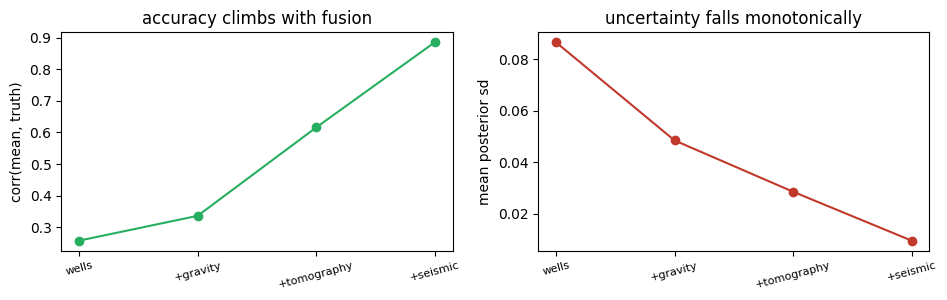

  wells          corr=0.258  mean sd=0.0867
  +gravity       corr=0.336  mean sd=0.0486
  +tomography    corr=0.616  mean sd=0.0286
  +seismic       corr=0.885  mean sd=0.0096


In [9]:
chain = [['wells'], ['wells', 'gravity'], ['wells', 'gravity', 'tomography'],
         ['wells', 'gravity', 'tomography', 'seismic']]
labels = ['wells', '+gravity', '+tomography', '+seismic']
corr, unc = [], []
for keys in chain:
    m, sd, _ = posterior(keys); corr.append(np.corrcoef(m, dphi_true[ridx])[0, 1]); unc.append(sd.mean())
fig, ax = panel(2, w=4.8, h=3.1)
ax[0].plot(range(4), corr, '-o', color='#27AE60'); ax[0].set_xticks(range(4)); ax[0].set_xticklabels(labels, rotation=15, fontsize=8)
ax[0].set(ylabel='corr(mean, truth)', title='accuracy climbs with fusion')
ax[1].plot(range(4), unc, '-o', color='#C0392B'); ax[1].set_xticks(range(4)); ax[1].set_xticklabels(labels, rotation=15, fontsize=8)
ax[1].set(ylabel='mean posterior sd', title='uncertainty falls monotonically'); plt.tight_layout(); plt.show()
for l, c, u in zip(labels, corr, unc): print(f'  {l:14s} corr={c:.3f}  mean sd={u:.4f}')

## 9. The posterior 3-D subsurface: mean and uncertainty

The joint posterior, in three dimensions: the mean porosity body recovers the draped reservoir, and the
uncertainty volume shows *where* we believe it -- tighter near the wells and where the rays cross, looser
over the un-drilled crest. With only six wells the crest itself carries real uncertainty, which is the
seed of the ensemble that follows.

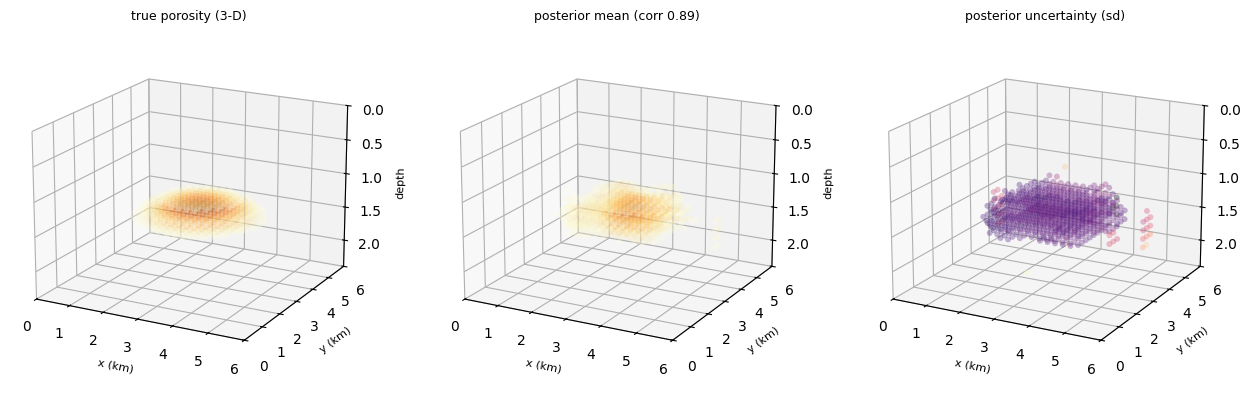

reconstruction corr 0.885; mean posterior sd 0.0096 (10% of contrast)


In [10]:
m_joint, sd_joint, Pinv = posterior(chain[-1])
M = np.zeros(N); M[ridx] = m_joint; S = np.zeros(N); S[ridx] = sd_joint
fig = plt.figure(figsize=(13, 4))
axA = fig.add_subplot(131, projection='3d'); render3d(axA, dphi_true, 'true porosity (3-D)')
axB = fig.add_subplot(132, projection='3d'); render3d(axB, M, f'posterior mean (corr {corr[-1]:.2f})')
axC = fig.add_subplot(133, projection='3d')
Sf = S.reshape(nx, ny, nz); mm = M.reshape(nx, ny, nz) > 0.25 * DPHI
axC.scatter(GX[mm], GY[mm], GZ[mm], c=Sf[mm], cmap='magma', s=18, alpha=0.32, edgecolor='none')
axC.set_xlim(0, Lx); axC.set_ylim(0, Ly); axC.set_zlim(Lz, 0); axC.view_init(elev=18, azim=-62)
axC.set_title('posterior uncertainty (sd)', fontsize=9)
axC.set_xlabel('x (km)', fontsize=8); axC.set_ylabel('y (km)', fontsize=8); axC.set_zlabel('depth', fontsize=8)
plt.tight_layout(); plt.show()
print(f'reconstruction corr {corr[-1]:.3f}; mean posterior sd {sd_joint.mean():.4f} ({sd_joint.mean()/DPHI:.0%} of contrast)')

## 10. The posterior as an ensemble: many possible earths

A mean and an error bar hide the *shape* of the uncertainty. The right object is the **ensemble**: draws
from the joint posterior, each a complete 3-D earth consistent with every datum, sampled through the
Cholesky factor of the posterior covariance. They agree where the data is strong (the well ties, the gross
mass) and disagree where it is weak (the crest, the flanks) -- different but equally valid hypotheses about
the rock. These are the realizations a reservoir team would carry forward.

drew 300 posterior realizations; crest location varies by 0.31 km across them


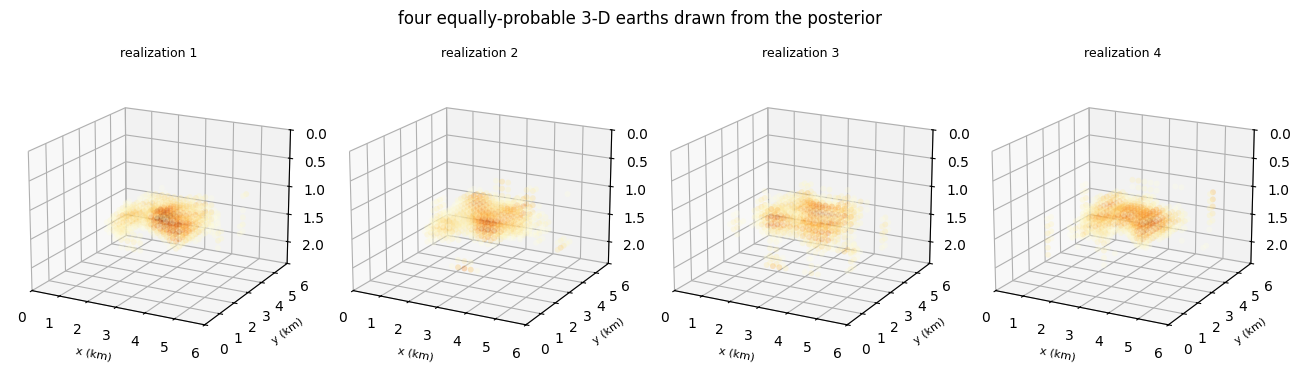

In [11]:
L = np.linalg.cholesky(Pinv + 1e-10 * np.eye(Nr))
NS = 300
ens = m_joint[:, None] + L @ rng.randn(Nr, NS)             # NS posterior realizations of the porosity field
crests = np.array([vx[np.argmax(ens[:, i])][:2] for i in range(NS)])
print(f'drew {NS} posterior realizations; crest location varies by {crests.std(0).mean():.2f} km across them')

fig = plt.figure(figsize=(13, 3.6))
for i in range(4):
    ax = fig.add_subplot(1, 4, i + 1, projection='3d')
    full = np.zeros(N); full[ridx] = ens[:, i]; render3d(ax, full, f'realization {i + 1}')
plt.suptitle('four equally-probable 3-D earths drawn from the posterior', y=1.02); plt.tight_layout(); plt.show()

## 11. The probabilistic reservoir: scenarios and their probabilities

The economic object is the **pay** -- rock with porosity above a reservoir cutoff. Across the ensemble,
each voxel has a posterior **probability of being pay**, `P(pay)`, which we render as a 3-D probability
volume: a solid green core the data insists on, fading to amber where the realizations disagree. We then
compress the ensemble into a few **geological scenarios** -- clustering realizations by their pay volume
and crest location -- and attach to each the share of posterior mass that falls in it: a representative
3-D earth with `P(scenario)`. Finally the posterior distribution of pay volume, with the P10/P50/P90 a
prospect is ranked on.

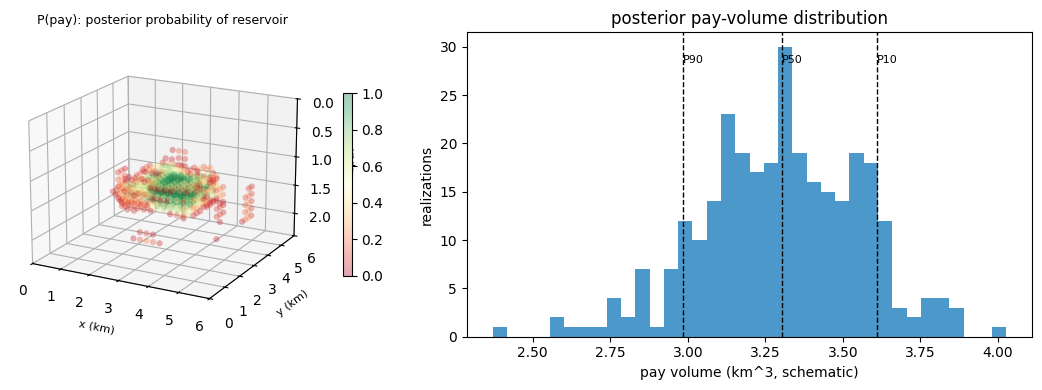

pay volume  P90=2.98  P50=3.30  P10=3.61  (P10/P90 = 1.21x spread)


In [12]:
cut = 0.45 * DPHI
pay = ens > cut                                            # (Nr, NS) boolean: is this voxel pay in each realization?
Ppay = pay.mean(1)                                         # per-voxel posterior probability of pay
Vpay = pay.sum(0) * dV                                     # pay volume per realization

# 3-D P(pay) probability volume
fig = plt.figure(figsize=(12, 4))
axP = fig.add_subplot(121, projection='3d')
PF = np.zeros(N); PF[ridx] = Ppay; PF = PF.reshape(nx, ny, nz); mm = PF > 0.05
sp = axP.scatter(GX[mm], GY[mm], GZ[mm], c=PF[mm], cmap='RdYlGn', s=20, alpha=0.35, vmin=0, vmax=1, edgecolor='none')
axP.set_xlim(0, Lx); axP.set_ylim(0, Ly); axP.set_zlim(Lz, 0); axP.view_init(elev=18, azim=-62)
axP.set_title('P(pay): posterior probability of reservoir', fontsize=9)
axP.set_xlabel('x (km)', fontsize=8); axP.set_ylabel('y (km)', fontsize=8); axP.set_zlabel('depth', fontsize=8)
fig.colorbar(sp, ax=axP, shrink=0.6)
axV = fig.add_subplot(122)
p10, p50, p90 = np.percentile(Vpay, [90, 50, 10])
axV.hist(Vpay, bins=36, color='#2E86C1', alpha=0.85)
for v, t in [(p90, 'P90'), (p50, 'P50'), (p10, 'P10')]:
    axV.axvline(v, c='k', ls='--', lw=1); axV.text(v, axV.get_ylim()[1] * 0.9, t, fontsize=8)
axV.set(xlabel='pay volume (km^3, schematic)', ylabel='realizations', title='posterior pay-volume distribution')
plt.tight_layout(); plt.show()
print(f'pay volume  P90={p90:.2f}  P50={p50:.2f}  P10={p10:.2f}  (P10/P90 = {p10/max(p90,1e-9):.2f}x spread)')

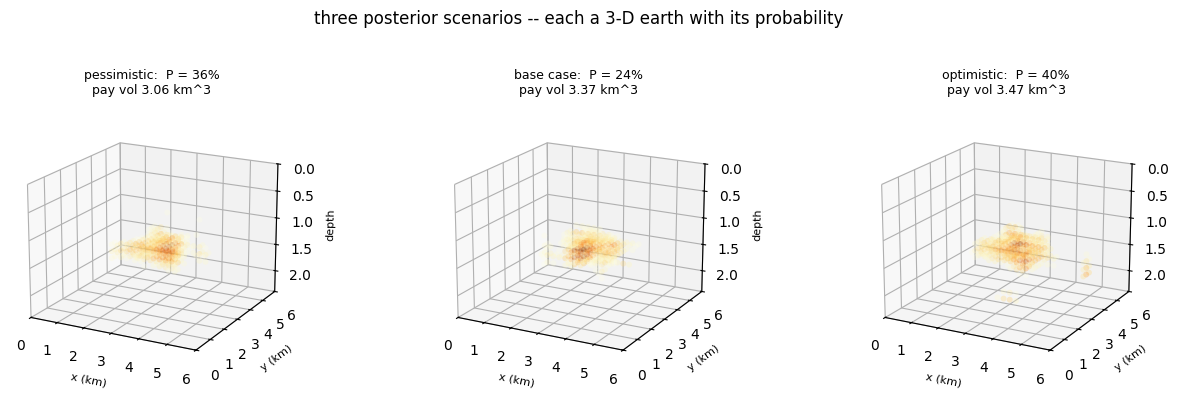

  pessimistic   P(scenario)=36%   mean pay volume 3.06 km^3
  base case     P(scenario)=24%   mean pay volume 3.37 km^3
  optimistic    P(scenario)=40%   mean pay volume 3.47 km^3


In [13]:
# cluster the ensemble into geological scenarios (k-means on standardized decision features)
feat = np.stack([Vpay, crests[:, 0], crests[:, 1]], 1)
Z = (feat - feat.mean(0)) / (feat.std(0) + 1e-9); K = 3
cen = Z[rng.choice(NS, K, replace=False)]
for _ in range(50):
    lab = np.argmin(((Z[:, None] - cen[None]) ** 2).sum(2), 1)
    cen = np.array([Z[lab == k].mean(0) if (lab == k).any() else cen[k] for k in range(K)])
order = np.argsort([Vpay[lab == k].mean() for k in range(K)])      # low -> high pay volume
names = ['pessimistic', 'base case', 'optimistic']
fig = plt.figure(figsize=(13, 3.8))
for j, k in enumerate(order):
    prob = (lab == k).mean()
    medoid = np.where(lab == k)[0][np.argmin(((Z[lab == k] - cen[k]) ** 2).sum(1))]
    full = np.zeros(N); full[ridx] = ens[:, medoid]
    ax = fig.add_subplot(1, 3, j + 1, projection='3d')
    render3d(ax, full, f'{names[j]}:  P = {prob:.0%}\npay vol {Vpay[lab==k].mean():.2f} km^3', cut=cut)
plt.suptitle('three posterior scenarios -- each a 3-D earth with its probability', y=1.03); plt.tight_layout(); plt.show()
for j, k in enumerate(order):
    print(f'  {names[j]:12s}  P(scenario)={ (lab==k).mean():.0%}   mean pay volume {Vpay[lab==k].mean():.2f} km^3')

## 12. The decision: Bayesian optimization for the next well

The ensemble makes the decision concrete. A new well is worth most where it is most *likely to find pay* --
where a large fraction of the posterior realizations carry reservoir in the column beneath. We make that
probability of success a function of `(x, y)`, evaluated over the ensemble, and let **Bayesian
optimization** (`mixle.doe`) search the field: it fits a surrogate to the locations it has tried and
proposes the next by expected improvement, finding the optimum in a few dozen evaluations.

Bayesian optimization over 32 evaluations in 0.6s
recommended next well at (x, y) = (3.94, 3.35) km, probability of pay = 100%


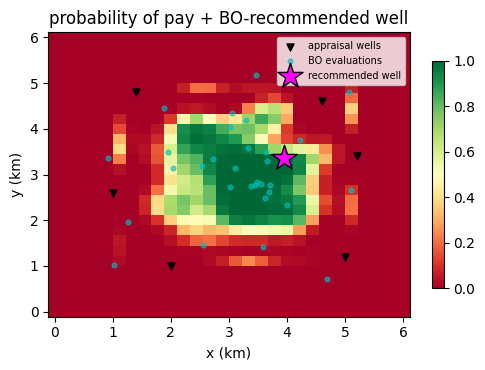

In [14]:
ENS_full = np.zeros((N, NS)); ENS_full[ridx] = ens
def prob_of_pay(p):
    xs, ys = p
    col = np.where((np.abs(vox[:, 0] - xs) < 0.4) & (np.abs(vox[:, 1] - ys) < 0.4))[0]
    if len(col) == 0: return 0.0
    return float((ENS_full[col].max(0) > cut).mean())      # fraction of realizations with pay in the column

t0 = time.time()
res = minimize(lambda p: -prob_of_pay(p), [(0.6, Lx - 0.6), (0.6, Ly - 0.6)],
               n_init=8, n_iter=24, seed=3, n_candidates=220, fit_kwargs={'max_its': 50})
print(f'Bayesian optimization over {len(res.y)} evaluations in {time.time() - t0:.1f}s')
print(f'recommended next well at (x, y) = ({res.best_x[0]:.2f}, {res.best_x[1]:.2f}) km, '
      f'probability of pay = {-res.best_y:.0%}')

izr = np.argmin(np.abs(gz - 1.35)); Pmap = (ENS_full.reshape(nx, ny, nz, NS) > cut).any(2).mean(2)
fig, ax = panel(1, w=5.2, h=3.8)
im = ax[0].pcolormesh(gx, gy, Pmap.T, cmap='RdYlGn', shading='auto', vmin=0, vmax=1); plt.colorbar(im, ax=ax[0], shrink=0.8)
ax[0].scatter(WELLXY[:, 0], WELLXY[:, 1], c='k', s=26, marker='v', label='appraisal wells')
ax[0].scatter(res.x[:, 0], res.x[:, 1], c='c', s=12, alpha=0.6, label='BO evaluations')
ax[0].scatter([res.best_x[0]], [res.best_x[1]], marker='*', s=360, c='magenta', edgecolor='k', label='recommended well')
ax[0].set(xlabel='x (km)', ylabel='y (km)', title='probability of pay + BO-recommended well'); ax[0].legend(fontsize=7)
plt.tight_layout(); plt.show()

## In short

We produced a posterior over a three-dimensional subsurface -- not a single model but a *distribution of
earths* -- by fusing four modalities through their physics, and used it to decide where to drill:

* a single **latent porosity field** coupled by rock physics to the **velocity** and **density** different
  instruments respond to -- one geology behind three fields;
* a **Helmholtz wave-equation PDE** (`mixle`'s differentiable sparse solver) and its Born operator
  for seismic, a **Newtonian potential** forward for gravity;
* a closed-form **joint Gaussian posterior** fusing seismic, gravity, wells and a tomography estimate,
  information adding in precision space, the uncertainty falling monotonically as each modality joins;
* an **ensemble** of 3-D realizations drawn from the posterior, turned into a `P(pay)` probability volume,
  **geological scenarios with probabilities**, and a posterior pay-volume distribution;
* **Bayesian optimization** that proposes the next well by probability of pay over the ensemble.

The rock physics is real (Hugoton-Panoma porosity and facies); the surveys are simulated forward from that
real-property earth and recovered -- the honest way to demonstrate a controlled joint inversion without
proprietary co-located data. The well geometry is illustrative and labelled as such.

## References

* Dubois, M.K., Bohling, G.C., Chakrabarti, S. (2007). Comparison of four approaches to a rock facies
  classification problem. *Computers & Geosciences* 33(5) -- the porosity/facies data
  (`github.com/seg/2016-ml-contest`).
* Tarantola, A. (2005). *Inverse Problem Theory and Methods for Model Parameter Estimation.* SIAM.
* Virieux, J., Operto, S. (2009). An overview of full-waveform inversion. *Geophysics* 74(6).
* Caers, J. (2011). *Modeling Uncertainty in the Earth Sciences* -- ensembles and geological scenarios.

## Exercises and extensions

1. **Real coregionalization.** Replace the deterministic rock-physics chain with a `FieldSystem`
   (`coregion=B`) of correlated velocity and density fields and infer the coupling `B`.
2. **Nonlinear FWI.** Swap the Born operator for the full Helmholtz forward inside `joint(...).fit(
   how='gauss_newton')` with frequency continuation.
3. **A third physics.** Add a DC-resistivity forward (`div(sigma grad phi)=source`, via `divergence_form`)
   tied to porosity through Archie's law.
4. **Connectivity scenarios.** Cluster the ensemble on reservoir *connectivity* (does a porous body link
   two wells?) instead of bulk features, and price the compartmentalization risk.
5. **Value of information.** Rank a gravity infill, a new seismic line, and an appraisal well by the
   expected reduction in posterior pay-volume variance before acquiring any of them.